<a href="https://colab.research.google.com/github/PonVo02/Customer-Churn-Analysis-Retention-Strategy-in-E-commerce-Python/blob/main/Customer_Churn_Analysis_%26_Retention_Strategy_in_E_commerce_VoVanPon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import + Load Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)

In [ ]:
df = pd.read_excel('/content/churn_prediction.xlsx')
df.columns = df.columns.str.lower().str.strip() # Change on column names to lowcase for easy to mention
df.head(3)

,customerid,churn,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
0,52869,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,NaN,229.53
1,52942,0,13.0,Computer,1,9.0,Cash on Delivery,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,NaN,9.0,234.38
2,52972,0,16.0,Mobile Phone,3,7.0,Debit Card,Male,3.0,4,Laptop & Accessory,3,Divorced,3,0,26.0,5.0,12.0,7.0,174.07


# QUESTION 1
- Churned users usually are new users → Provide more promotion for new users, or increase the new users experience
- Churned users usually receive less cashback than not churn → Increase the cashback ratio
- Churned users complain more → deep dive what these churned users complain about, and provide the solution

## 1. Data quality

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customerid                   5630 non-null   int64  
 1   churn                        5630 non-null   int64  
 2   tenure                       5366 non-null   float64
 3   preferredlogindevice         5630 non-null   object 
 4   citytier                     5630 non-null   int64  
 5   warehousetohome              5379 non-null   float64
 6   preferredpaymentmode         5630 non-null   object 
 7   gender                       5630 non-null   object 
 8   hourspendonapp               5375 non-null   float64
 9   numberofdeviceregistered     5630 non-null   int64  
 10  preferedordercat             5630 non-null   object 
 11  satisfactionscore            5630 non-null   int64  
 12  maritalstatus                5630 non-null   object 
 13  numberofaddress   

### Missing + duplicates + shape

In [ ]:
print("Shape:", df.shape)

# duplicates
print("Duplicates:", df.duplicated().sum())

# missing values

missing = df.isna().mean().sort_values(ascending = False)
missing

Shape: (5630, 20)
Duplicates: 0


,0
daysincelastorder,0.054529
orderamounthikefromlastyear,0.047069
tenure,0.046892
ordercount,0.045826
couponused,0.045471
hourspendonapp,0.045293
warehousetohome,0.044583
customerid,0.000000
preferredlogindevice,0.000000
churn,0.000000


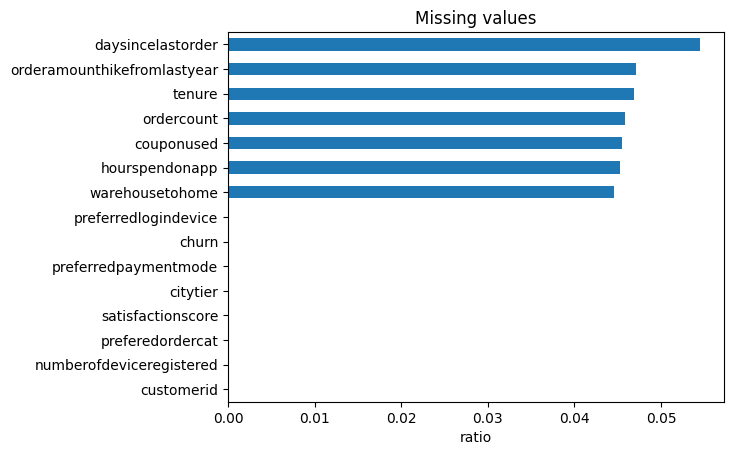

In [ ]:
# missing value
plt.figure()
missing.head(15).sort_values().plot(kind = "barh")
plt.title("Missing values")
plt.xlabel("ratio")
plt.show()

### Class imbalance

Churn rate:
 churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64


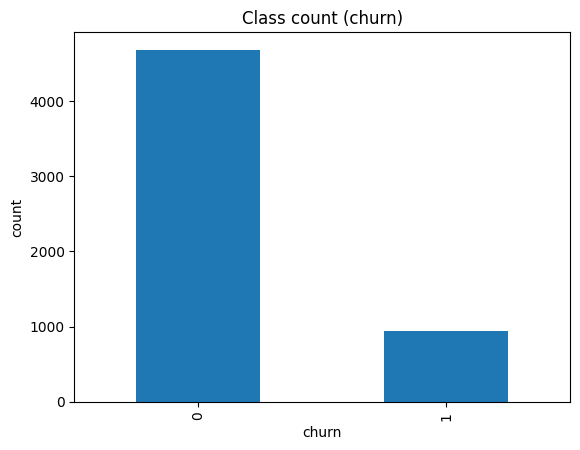

In [ ]:
target = 'churn'
rate = df[target].value_counts(normalize=True)
print("Churn rate:\n", rate)

plt.figure()
df[target].value_counts().plot(kind = "bar")
plt.title("Class count (churn)")
plt.xlabel("churn")
plt.ylabel("count")
plt.show()

### Outlier check

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.drop(target, errors = "ignore")

outlier_rates = []
for c in num_cols:
  x = df[c].dropna()
  if x.nunique() < 10:
    continue

  q1, q3 = x.quantile(0.25), x.quantile(0.75)
  iqr = q3 - q1
  if iqr == 0:
    continue

  lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
  out_rate = ((x < lower) | (x > upper)).mean()
  outlier_rates.append((c, out_rate))

outlier_rates = sorted(outlier_rates, key = lambda x: x[1], reverse = True)
out_df = pd.DataFrame(outlier_rates, columns = ["col", "out_rate"])
print("Top outlier rates:")
for c, r in outlier_rates[:10]:
  print(f"{c}: {r:.2%}")


Top outlier rates:
ordercount: 13.09%
couponused: 11.70%
cashbackamount: 7.78%
daysincelastorder: 1.16%
orderamounthikefromlastyear: 0.62%
tenure: 0.07%
numberofaddress: 0.07%
warehousetohome: 0.04%
customerid: 0.00%


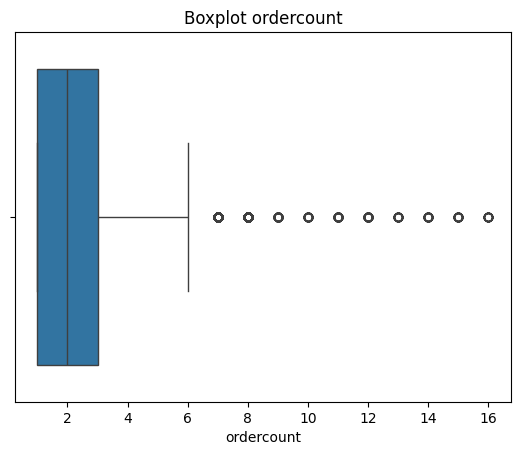

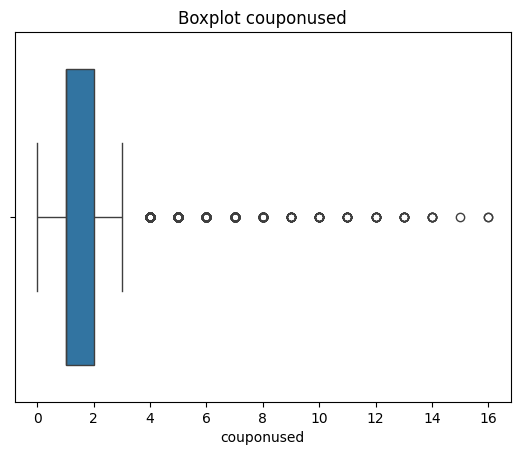

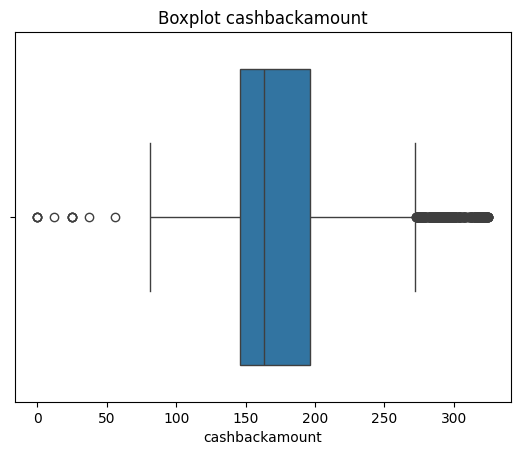

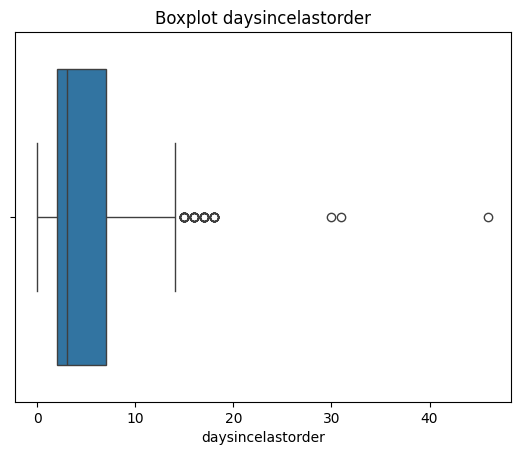

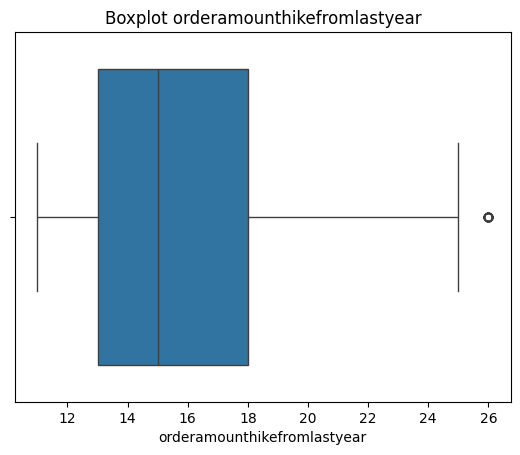

In [ ]:
top_out_cols = out_df["col"].head(5).tolist()
for c in top_out_cols:
  plt.figure()
  sns.boxplot(x=df[c])
  plt.title(f"Boxplot {c}")
  plt.show()

##1.1 Clean "same meaning"

In [ ]:
if "preferredlogindevice" in df.columns:
  df["preferredlogindevice"] = df["preferredlogindevice"].replace({"Mobile Phone": "Phone"})

if "preferredpaymentmode" in df.columns:
  df["preferredpaymentmod"] = df["preferredpaymentmode"].replace({
      "CC": "Credit Card",
      "COD": "Cash on Delivery"
  })

if "preferedordercat" in df.columns:
  df["preferedordercat"] = df["preferedordercat"].replace({
      "Mobile Phone": "Phone"
  })
# recheck unique quick
obj_cols = df.select_dtypes(include = "object").columns
for c in obj_cols:
  print(f"{c}: {df[c].unique()}")

preferredlogindevice: ['Phone' 'Computer']
preferredpaymentmode: ['E wallet' 'Cash on Delivery' 'Debit Card' 'UPI' 'Credit Card' 'COD' 'CC']
gender: ['Female' 'Male']
preferedordercat: ['Fashion' 'Laptop & Accessory' 'Phone' 'Grocery' 'Mobile' 'Others']
maritalstatus: ['Married' 'Single' 'Divorced']
preferredpaymentmod: ['E wallet' 'Cash on Delivery' 'Debit Card' 'UPI' 'Credit Card']


## 1.2 Base model (RandomForest)

In [ ]:
drop_cols = [c for c in ["customerid"] if c in df.columns]

X = df.drop(columns =[target] + drop_cols)
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state= 42,
    stratify = y
)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers = [
        ("num", Pipeline([("imputer", SimpleImputer(strategy = "median"))]), num_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown= "ignore"))]), cat_cols)
    ]
)
base_rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    class_weight = "balanced_subsample",
    n_jobs = -1
)

pipe_rf = Pipeline([("prep", preprocess), ("model", base_rf)])
pipe_rf.fit(X_train, y_train)

proba = pipe_rf.predict_proba(X_test)[:,1]
print("Base RF ROC-AUC:", roc_auc_score(y_test, proba))
print("Base RF PR-AUC:", average_precision_score(y_test, proba))


Base RF ROC-AUC: 0.9937865497076024
Base RF PR-AUC: 0.9741362580077308


### Visualize Random Forest (importance feature)

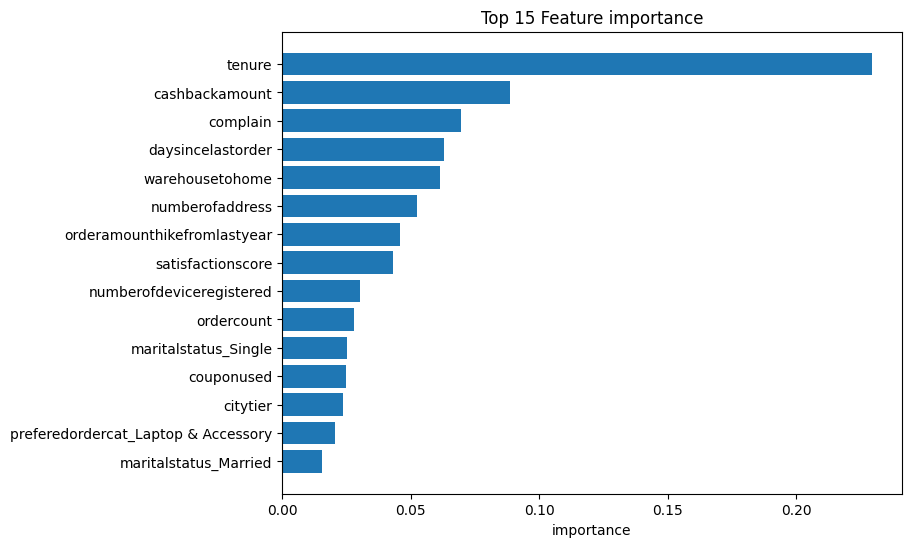

,feature,importance
0,tenure,0.229698
12,cashbackamount,0.088689
7,complain,0.069552
11,daysincelastorder,0.062848
2,warehousetohome,0.061491
6,numberofaddress,0.052697
8,orderamounthikefromlastyear,0.045839
5,satisfactionscore,0.043310
4,numberofdeviceregistered,0.030541
10,ordercount,0.027899


In [ ]:
ohe = pipe_rf.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols) if len(cat_cols) else []
feature_names = np.array(num_cols + list(cat_feature_names))

importance = pipe_rf.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importance})
imp_df = imp_df.sort_values("importance", ascending = False).head(15)

plt.figure(figsize=(8,6))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
plt.title("Top 15 Feature importance")
plt.xlabel("importance")
plt.show()

imp_df

As Feature Importance show, we can see these features can have high relation with target columns:

- Tenure
- Cashback amount
- Complain
- Distance from warehouse to home
- Days since Last order

→ We will analyse and visualize these features for more insights.

## 1.3 Analyse features from initial Random Forest model:

- Tenure
- Cashback amount
- Complain
- Distance from warehouse to home
- Days since Last order

In [ ]:
focus = ["tenure", "cashbackamount", "complain", "warehousetohome","daysincelastorder"]
# targe =churn

# check column
missing_cols = [c for c in focus + [target] if c not in df.columns]

def churn_rate_by_bins(df, col, bins=6, qcut=True):
  s = df[[col, target]].dropna()
  if qcut:
    s["bin"] = pd.qcut(s[col], q=bins, duplicates = "drop")
  else:
    s["bin"] = pd.qcut(s[col], bins=bins)
  out = s.groupby("bin").agg(
      n=(target, "size"),
      churn_rate=(target, "mean"),
      mean_value = (col, "mean")
  ).reset_index()
  return out.sort_values("bin")

### **1.3.1: tenure**

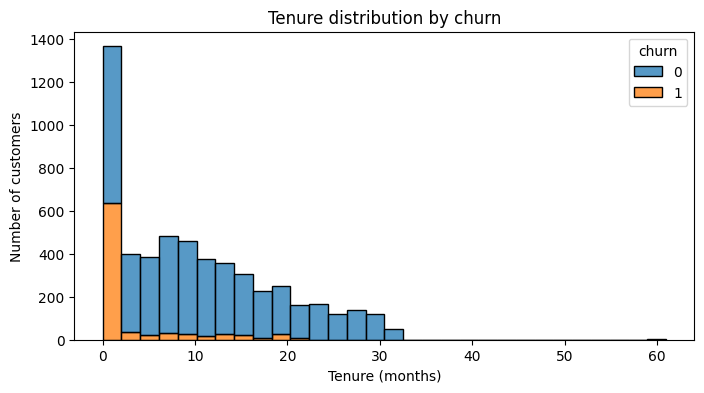

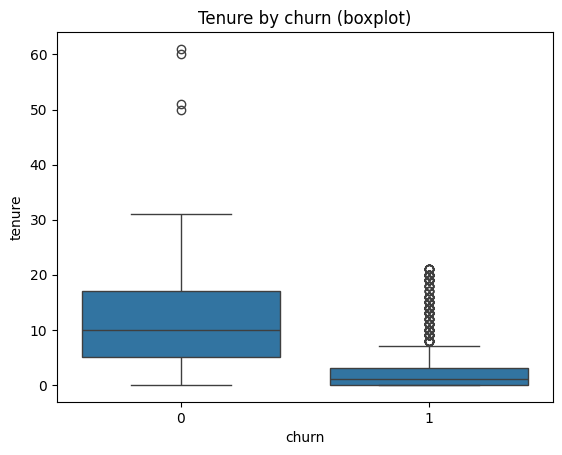

In [ ]:
# Distribution by churn + boxplot

plt.figure(figsize=(8,4))
sns.histplot( data=df, x="tenure",hue="churn", bins=30,multiple="stack"
)
plt.title("Tenure distribution by churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of customers")
plt.show()

plt.figure()
sns.boxplot(data=df, x="churn", y="tenure")
plt.title("Tenure by churn (boxplot)")
plt.show()


/tmp/ipython-input-902744910.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = s.groupby("bin").agg(


,bin,n,churn_rate,mean_value
0,"(-0.001, 1.0]",1198,0.518364,0.575960
1,"(1.0, 5.0]",769,0.088427,3.577373
2,"(5.0, 9.0]",914,0.056893,7.628009
3,"(9.0, 13.0]",770,0.057143,11.429870
4,"(13.0, 19.0]",853,0.065651,16.305979
5,"(19.0, 61.0]",862,0.030162,25.006961


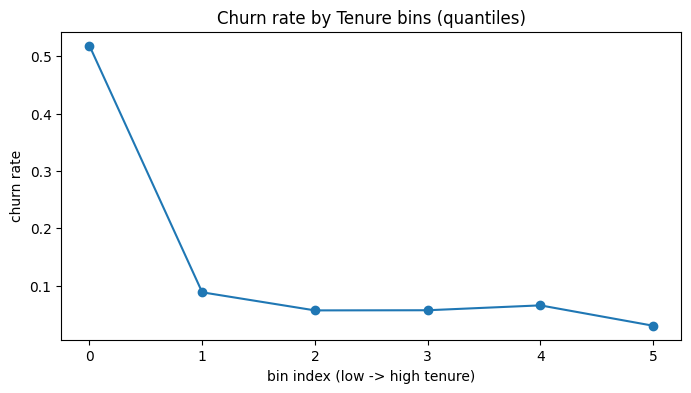

In [ ]:
# Churn rate by tenure bins

tenure_bins = churn_rate_by_bins(df, "tenure", bins=6, qcut=True)
display(tenure_bins)

plt.figure(figsize=(8,4))
plt.plot(range(len(tenure_bins)), tenure_bins["churn_rate"], marker="o")
plt.title("Churn rate by Tenure bins (quantiles)")
plt.xlabel("bin index (low -> high tenure)")
plt.ylabel("churn rate")
plt.show()

**Histogram**
- churn rate = 1 accumulates almost entirely in tenure 0-3
- non-churn span 30-60

**Boxplot**
- Median tenure churn ~ 1-2 month
- Median tenure churn ~ 10 month
- The churn group has a narrow distribution

**Tenure Bins**
- The churn probability drops sharply from approximately 50-52% in the first month to below 10% afterward and further declines to about 3% among long-tenure customers.

-> **Insight:**
  - The comapany is not losing cusotomers after thay become engaged
  - the company is losing customer before thay become real users
  
Customer churn is heavily concentrated among early-tenure users. Churned customers show a median tenure of approximately 1–2 months, compared to about 10 months for retained customers, with minimal overlap between the two distributions. This indicates that churn occurs during the onboarding and trial stages rather than among long-term users. Therefore, the issue reflects a customer activation failure rather than a loyalty problem.


### **1.3.2: CashbackAmount**

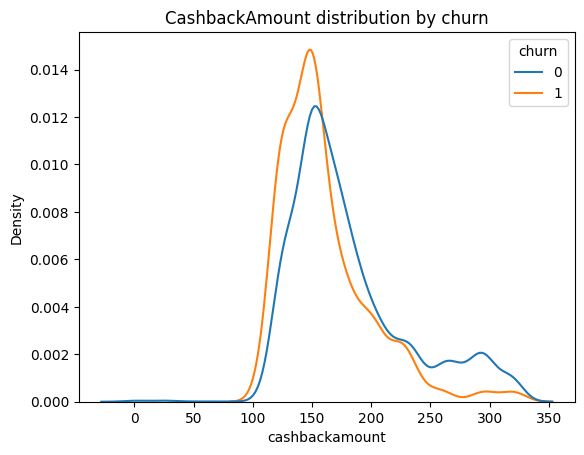

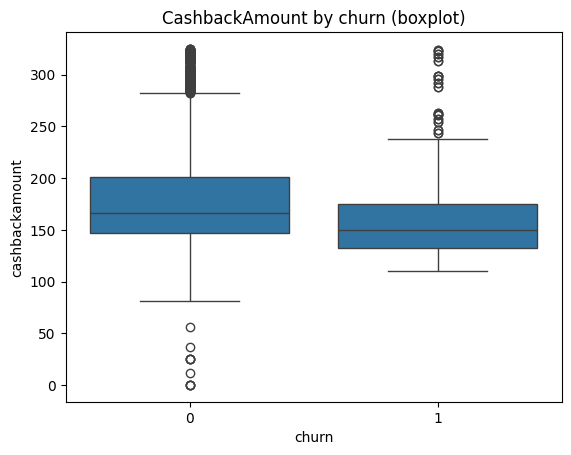

In [ ]:
# Distribution + boxplot
plt.figure()
sns.kdeplot(data=df, x="cashbackamount", hue="churn", common_norm=False)
plt.title("CashbackAmount distribution by churn")
plt.show()

plt.figure()
sns.boxplot(data=df, x="churn", y="cashbackamount")
plt.title("CashbackAmount by churn (boxplot)")
plt.show()

/tmp/ipython-input-902744910.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = s.groupby("bin").agg(


,bin,n,churn_rate,mean_value
0,"(-0.001, 135.8]",940,0.274468,124.351819
1,"(135.8, 150.0]",940,0.236170,144.770021
2,"(150.0, 163.28]",935,0.162567,155.560075
3,"(163.28, 181.05]",939,0.112886,171.614526
4,"(181.05, 222.248]",937,0.140875,198.097439
5,"(222.248, 324.99]",939,0.083067,268.987348


Text(0, 0.5, 'churn rate')

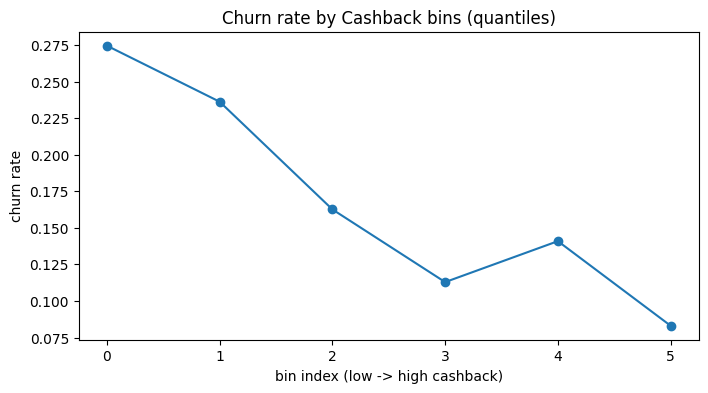

In [ ]:
# Churn rate by cashback bin
cash_bins = churn_rate_by_bins(df, "cashbackamount", bins=6, qcut=True)
display(cash_bins)

plt.figure(figsize=(8,4))
plt.plot(range(len(cash_bins)), cash_bins["churn_rate"], marker="o")
plt.title("Churn rate by Cashback bins (quantiles)")
plt.xlabel("bin index (low -> high cashback)")
plt.ylabel("churn rate")

**Insight**
- Churned users tend to receive lower cashback. The churn group’s cashback distribution is shifted lower, and the median cashback for churn is below the non-churn group -> cashback looks like a strong retention lever.
- Churn rate drops as cashback increases (clear gradient). In quantile bins, churn rate falls from ~27% (low cashback, mean ~124) down to ~8% (high cashback, mean ~269). This is a big reduction and consistently supports the **“more cashback -> lower churn” relationship**.

### **1.3.3 Complain**

,count,churn_rate
complain,,
0,4026,0.109290
1,1604,0.316708


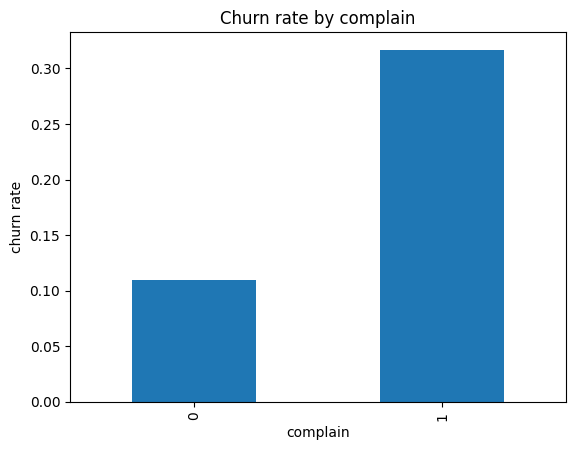

In [ ]:
# churn rate by complain

tmp = df.groupby("complain")["churn"].agg(["count","mean"]).rename(columns={"mean":"churn_rate"})
display(tmp)

plt.figure()
tmp["churn_rate"].plot(kind="bar")
plt.title("Churn rate by complain")
plt.xlabel("complain")
plt.ylabel("churn rate")
plt.show()

**Insight**
- Complaints are strongly linked to churn. Customers who filed a complaint have a churn rate of ~31.7%, compared to ~10.9% for customers with no complaints.
- This suggests churn is not only about pricing/promotion — service experience and issue resolution are major churn drivers. Even a small number of unresolved complaints can translate into a large churn impact.

### **1.3.4: DaysSineLastOrder**

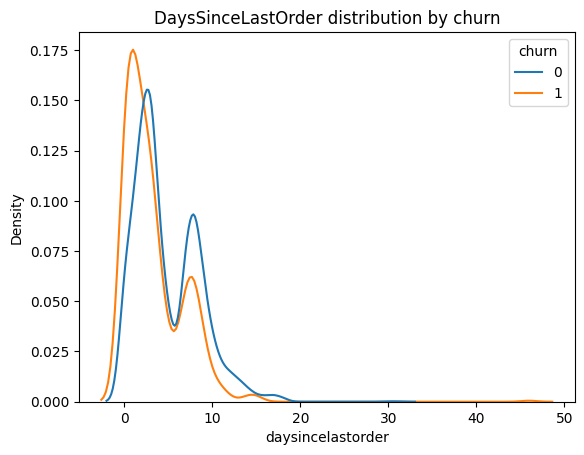

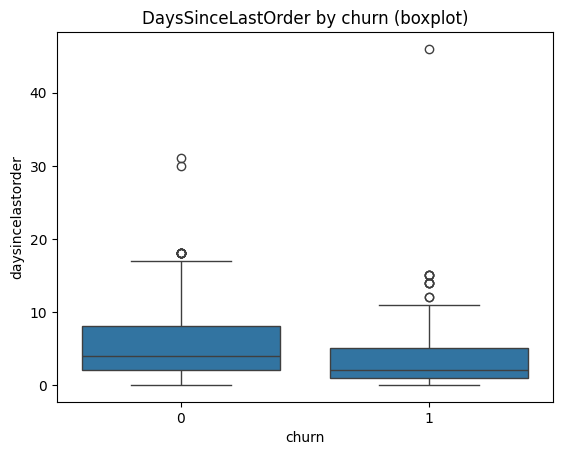

In [ ]:
# Distribution + boxplot

plt.figure()
sns.kdeplot(data=df, x="daysincelastorder", hue="churn", common_norm=False)
plt.title("DaysSinceLastOrder distribution by churn")
plt.show()

plt.figure()
sns.boxplot(data=df, x="churn", y="daysincelastorder")
plt.title("DaysSinceLastOrder by churn (boxplot)")
plt.show()

/tmp/ipython-input-902744910.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = s.groupby("bin").agg(


,bin,n,churn_rate,mean_value
0,"(-0.001, 1.0]",1110,0.317117,0.553153
1,"(1.0, 2.0]",792,0.154040,2.000000
2,"(2.0, 3.0]",900,0.144444,3.000000
3,"(3.0, 6.0]",772,0.132124,4.588083
4,"(6.0, 8.0]",985,0.132995,7.546193
5,"(8.0, 46.0]",764,0.074607,10.879581


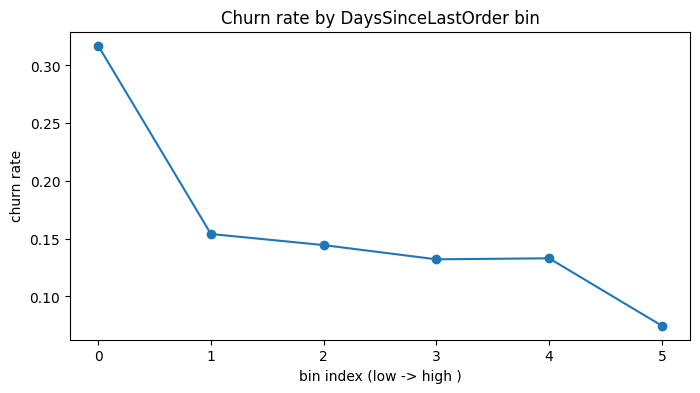

In [ ]:
# Churn rate DaysSinceLastOrder by bins

dsl_bins = churn_rate_by_bins(df, "daysincelastorder", bins=6, qcut=True)
display(dsl_bins)

plt.figure(figsize = (8,4))
plt.plot(range(len(dsl_bins)), dsl_bins["churn_rate"], marker="o")
plt.title("Churn rate by DaysSinceLastOrder bin")
plt.xlabel("bin index (low -> high )")
plt.ylabel("churn rate")
plt.show()

**Insight**
- Churn highest when customers have very recent last orders. **In the lowest bin (<= ~1 day, mean ~0.55), churn rate is ~31.7%**— the highest among all bins. This suggests many churned users are “new/early-stage” customers who drop off soon after their first few purchases => **activation problem**.
- Churn decreases as the gap since last order increases. As DaysSinceLastOrder rises, churn rate drops from ~31.7% to ~15% and keeps trending down, reaching ~7.5% in the highest bin. This indicates longer-gap users in this dataset are not necessarily “lost” — they may be stable/seasonal buyers or customers with different purchase cycles.
  - In this dataset, customers who haven not  purchased for longer are not necessarily churned. Some may simply buy less frequently. Therefore, DaysSinceLastOrder should be combined with (tenure, complain, cashback) when defining at-risk customers.

### **1.3.5: WarehouseToHome**

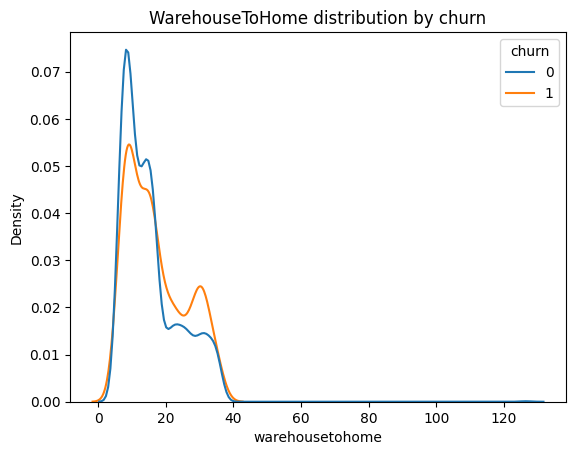

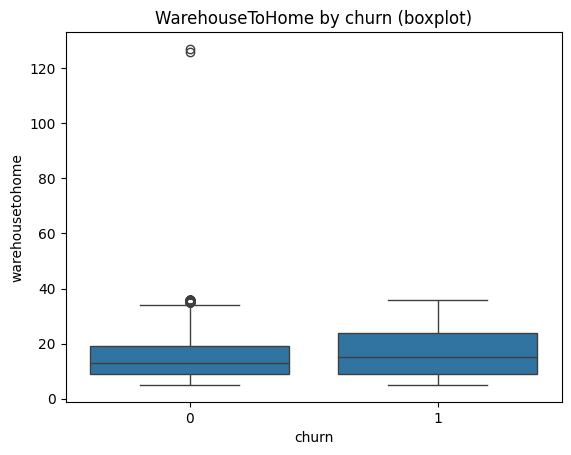

In [ ]:
# Distribution + boxplot
plt.figure()
sns.kdeplot(data=df, x="warehousetohome", hue="churn", common_norm=False)
plt.title("WarehouseToHome distribution by churn")
plt.show()

plt.figure()
sns.boxplot(data=df, x="churn", y="warehousetohome")
plt.title("WarehouseToHome by churn (boxplot)")
plt.show()

/tmp/ipython-input-902744910.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = s.groupby("bin").agg(


,bin,n,churn_rate,mean_value
0,"(4.999, 8.0]",1136,0.125000,7.117077
1,"(8.0, 10.0]",833,0.148860,9.328932
2,"(10.0, 14.0]",1002,0.131737,12.612774
3,"(14.0, 17.0]",827,0.162031,15.914148
4,"(17.0, 25.0]",694,0.204611,21.582133
5,"(25.0, 127.0]",887,0.214205,30.996618


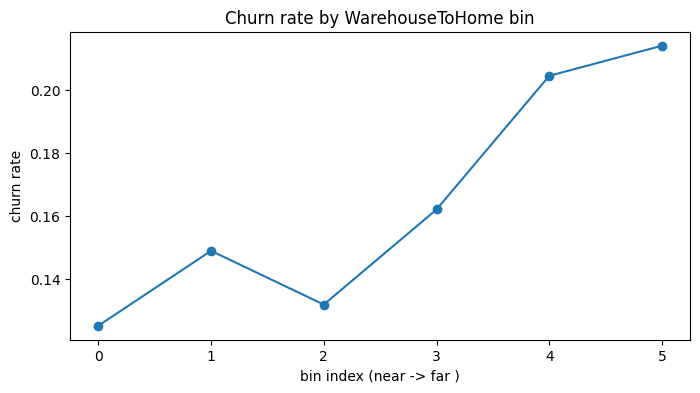

In [ ]:
# Churn Rate by bins
wh_bins = churn_rate_by_bins(df, "warehousetohome", bins=6, qcut=True)
display(wh_bins)

plt.figure(figsize = (8,4))
plt.plot(range(len(wh_bins)), wh_bins["churn_rate"], marker="o")
plt.title("Churn rate by WarehouseToHome bin")
plt.xlabel("bin index (near -> far )")
plt.ylabel("churn rate")
plt.show()

**Insight**
- Churn increases as customers live farther from the warehouse. In the bin anlysis, churn rate rises from ~12.5% (nearses group, mean distance ~7.1) to ~ 21.4%(farthest group, mean distance ~31%).
- Churned users have a higher typical distance. The distribution,boxplot show the churn group is slightly shifted to higher WarehouseToHome, with a higher median and wider spread—more churn users fall into the “mid–far” range.

### **1.3.6: Tennure vs DaysSinceLastOrder**

/tmp/ipython-input-1869564500.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = tmp.pivot_table(values="churn",index="tenure_bin", columns="inative_bin", aggfunc = "mean")


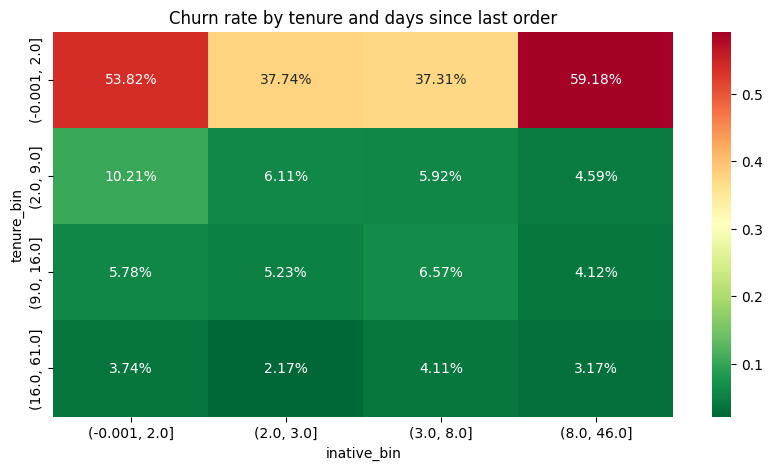

In [ ]:
# is wich group is churn concentrated (new - inactive)?
tmp = df[["tenure","daysincelastorder","churn"]].dropna().copy()
tmp["tenure_bin"] = pd.qcut(tmp["tenure"], 4, duplicates = "drop")
tmp["inative_bin"] = pd.qcut(tmp["daysincelastorder"], 4, duplicates="drop")

pivot = tmp.pivot_table(values="churn",index="tenure_bin", columns="inative_bin", aggfunc = "mean")
plt.figure(figsize=(10,5))
sns.heatmap(pivot,
            annot=True,
            fmt=".2%",
            cmap="RdYlGn_r") # color (churn rate) green -> red
plt.title("Churn rate by tenure and days since last order")
plt.show()

**insight**
- Churn is heavily concentrated among new users (tenure <= ~ 2 months), regardless of inactivity level. In the lowest tenure quartile, churn is extremely high across all inactivity bins (~ 37% – 59%). This confirms the main problem is early activation/onboarding, not long-term retention.

- Once customers pass the early stage (tenure > ~2 months), churn drops sharply and stays low.In other words, after users become real/engaged customers, churn becomes much less frequent.
- In the new-user group, even customers with longer days since last order still show high churn. But in longer-tenure groups, inactivity has a smaller impact. This means tenure is the key context for interpreting DaysSinceLastOrder.

  - => “Inactivity” alone is not a reliable churn signal without tenure.

### **1.3.7 Complain vs WarehouseToHome**

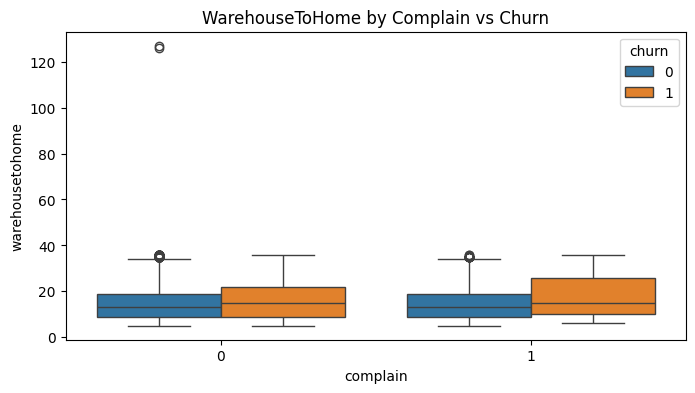

In [ ]:
tmp = df[["complain","warehousetohome","churn"]].dropna().copy()
plt.figure(figsize= (8,4))
sns.boxplot(data=tmp, x="complain", y="warehousetohome", hue="churn")
plt.title("WarehouseToHome by Complain vs Churn")
plt.show()

**Insight**
- Distance amplifies churn risk, especially for customers who complain. In both complain groups (0 and 1), the churned users tend to have higher WarehouseToHome (higher median and wider spread) than non-churn users.
- The most risky group is complain=1 and away from the repository: when the guest has a complain and is away, the probability of churn is higher. This suggests delivery experience with issues arise that make it easy for customers to leave.
- With complain=0, “away from the warehouse” still has an effect but is milder. The distance between churn and non-churn is unclear by group with complain.

**Insight (EDA) - Recommendations**

**What we see**

- Churn mainly happens very early. Most churn users have tenure ~0–2 months. After customers stay past this stage, churn drops to a low level -> the problem is activation/first-month experience, not long-term loyalty.

- Cashback is strongly related to retention. Lower cashback groups show much higher churn; higher cashback groups churn less -> cashback is a practical lever to reduce churn, especially for new users.

- Complaints are a red flag. Customers with complain=1 churn much more than those with no complaints -> unresolved issues directly push users to leave.

- Logistics friction matters. Customers living farther from the warehouse have higher churn, and the risk is even worse when combined with complaints -> delivery/ETA issues likely contribute to churn.

- DaysSinceLastOrder should not be used alone. Its meaning changes by tenure. For new users, churn is high regardless of inactivity; for longer-tenure users, churn is low overall -> always read DaysSinceLastOrder together with tenure + complain + cashback.

**recommendations**

1. Fix the first 30–60 days (highest impact).
Improve onboarding + first/second order experience, and set early follow-ups (Day 0–3, Week 1) to prevent early drop-off.

2. Prioritize complaint handling before promotions.
Fast resolution + proactive follow-up. Use apology credit/free ship only after the issue is solved.

3. Target cashback smarter (don’t give to everyone).
Focus incentives on new users + low cashback (and/or complaint users). This reduces churn while controlling promo cost.

4. Reduce churn in far-distance zones.
Improve ETA transparency, shipping options, and support for customers far from warehouses. Prioritize the segment far + complain.



# QUESTION 2

## 2. Model Training vs Evaluation

### 2.1 Split train/ test set

In [ ]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

val_size = 0.15 / (1 - 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=val_size, random_state=42, stratify=y_train_full
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")


Training set size: 3940
Validation set size: 845
Test set size: 845


### 2.2 Feature Transforming

In [ ]:
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocess_tree = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

preprocess_linear = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
])

### 2.3 Baseline model

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score

baseline = Pipeline([
    ("prep", preprocess_tree),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)
pred_val = baseline.predict(X_val)
proba_val = baseline.predict_proba(X_val)[:,1]

print("balanced_acc:", balanced_accuracy_score(y_val, pred_val))
print("precision:", precision_score(y_val, pred_val))
print("recall:", recall_score(y_val, pred_val))
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("PR-AUC:", average_precision_score(y_val, proba_val))


balanced_acc: 0.5
precision: 0.0
recall: 0.0
ROC-AUC: 0.5
PR-AUC: 0.1680473372781065


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 2.4 Compare model

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score

models = {
    "LogisticRegression": Pipeline([
        ("prep", preprocess_linear),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "DecisionTree": Pipeline([
        ("prep", preprocess_tree),
        ("model", DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"))
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocess_tree),
        ("model", RandomForestClassifier(
            n_estimators=200, random_state=42,
            class_weight="balanced_subsample", n_jobs=-1
        ))
    ]),
    "GradientBoosting": Pipeline([
        ("prep", preprocess_tree),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
}

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    results.append({
        "model": name,
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "roc_auc": roc_auc_score(y_val, y_proba),
        "pr_auc": average_precision_score(y_val, y_proba),
    })
    trained[name] = model

results_df = pd.DataFrame(results).sort_values("balanced_accuracy", ascending=False)
display(results_df)


,model,precision,recall,balanced_accuracy,roc_auc,pr_auc
2,RandomForest,0.966667,0.816901,0.905606,0.992422,0.970075
0,LogisticRegression,0.469231,0.859155,0.831427,0.909172,0.728094
1,DecisionTree,0.455598,0.830986,0.815208,0.881729,0.641258
3,GradientBoosting,0.837838,0.654930,0.814663,0.947068,0.803314


### 2.5 Enhance RandomForest model

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, average_precision_score, confusion_matrix

rf_pipe = Pipeline([
    ("prep", preprocess_tree),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

param_grid_light = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__bootstrap": [True, False]
}

grid_search = GridSearchCV(
    rf_pipe,
    param_grid_light,
    cv=5,
    scoring="balanced_accuracy"
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

# Re- apply on Validation
val_pred = best_rf.predict(X_val)
val_proba = best_rf.predict_proba(X_val)[:, 1]

print("\nTuned RF (VAL) balanced_acc:", balanced_accuracy_score(y_val, val_pred))
print("Tuned RF (VAL) PR-AUC:", average_precision_score(y_val, val_proba))
print("VAL Confusion matrix:\n", confusion_matrix(y_val, val_pred))


Best params: {'model__bootstrap': False, 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Tuned RF (VAL) balanced_acc: 0.9443030873720273
Tuned RF (VAL) PR-AUC: 0.9752665110183177
VAL Confusion matrix:
 [[694   9]
 [ 14 128]]


### 2.6 Final evaluation on Test

In [ ]:
test_pred = best_rf.predict(X_test)
test_proba = best_rf.predict_proba(X_test)[:, 1]

print("Tuned RF (TEST) PR-AUC:", average_precision_score(y_test, test_proba))
print("TEST Confusion matrix:", confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, digits = 4))

Tuned RF (TEST) PR-AUC: 0.9758228288966266
TEST Confusion matrix: [[696   7]
 [ 16 126]]
              precision    recall  f1-score   support

           0     0.9775    0.9900    0.9837       703
           1     0.9474    0.8873    0.9164       142

    accuracy                         0.9728       845
   macro avg     0.9624    0.9387    0.9501       845
weighted avg     0.9725    0.9728    0.9724       845



After tuning, RandomForest shows strong performance on test (**PR-AUC = 0.976**).

The model correctly identifies **126 churn users** while making only **7 false alarms** and missing **16 churn users**.

This is suitable for targeted retention campaigns -> **final model selected: Tuned RandomForest**.

# **QUESTION 3**
- Use K-Means to clustering churn-users groups.
- Find the insight between the groups


## 1. Get the data prepared

In [ ]:
#Prepare data:
df_churned = df[df["churn"] == 1].copy()

df_churned_feat = df_churned.drop(columns=["customerid","churn"], errors="ignore")

print(df_churned_feat.shape)
df_churned_feat.head()

(948, 19)


,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount,preferredpaymentmod
7,1.0,Computer,1,17.0,Credit Card,Female,4.0,5,Phone,4,Single,3,1,26.0,2.0,2.0,1.0,143.59,Credit Card
24,1.0,Computer,1,17.0,Credit Card,Female,4.0,5,Phone,4,Single,3,1,26.0,1.0,2.0,1.0,143.59,Credit Card
40,NaN,Computer,1,16.0,CC,Female,3.0,4,Phone,4,Single,2,1,25.0,1.0,1.0,0.0,118.59,Credit Card
58,NaN,Computer,1,16.0,CC,Female,3.0,4,Phone,4,Single,2,1,25.0,0.0,1.0,0.0,118.59,Credit Card
68,1.0,Computer,1,14.0,Debit Card,Male,4.0,6,Laptop & Accessory,3,Single,3,1,25.0,2.0,2.0,7.0,185.74,Debit Card


In [ ]:
# Transform data
from sklearn.preprocessing import MinMaxScaler

cate_cols = df_churned_feat.select_dtypes(include="object").columns.tolist()

#one-hot encode
encoded_df = pd.get_dummies(df_churned_feat, columns=cate_cols, drop_first=True)

#scale
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(encoded_df)
scaled_df = pd.DataFrame(scaled_data, columns=encoded_df.columns)


In [ ]:
scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 867 non-null    float64
 1   citytier                               948 non-null    float64
 2   warehousetohome                        864 non-null    float64
 3   hourspendonapp                         890 non-null    float64
 4   numberofdeviceregistered               948 non-null    float64
 5   satisfactionscore                      948 non-null    float64
 6   numberofaddress                        948 non-null    float64
 7   complain                               948 non-null    float64
 8   orderamounthikefromlastyear            934 non-null    float64
 9   couponused                             940 non-null    float64
 10  ordercount                             930 non-null    float64
 11  daysin

In [ ]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

#Impute missing
imputer = SimpleImputer(strategy="median")
scaled_imputed = pd.DataFrame(imputer.fit_transform(scaled_df), columns=scaled_df.columns)

#PCA
pca = PCA(n_components= 3, random_state=42)
pca_df = pd.DataFrame(pca.fit_transform(scaled_imputed), columns=["PC1", "PC2", "PC3"])
pca_df.head()

,PC1,PC2,PC3
0,-0.407124,-0.615494,1.334313
1,-0.407149,-0.615048,1.334475
2,-0.130999,-0.336221,1.116927
3,-0.131024,-0.335775,1.117089
4,1.091798,0.157855,0.213965


In [ ]:
pca.explained_variance_ratio_

array([0.16076205, 0.12485566, 0.10519973])

We applied PCA (3 components) to visualize churned users in lower dimensions. The first 3 PC's' explain ~39% of the variance, indicating the data is high-dimensional

## 2. Apply KMeans model

### 2.1 Choose K

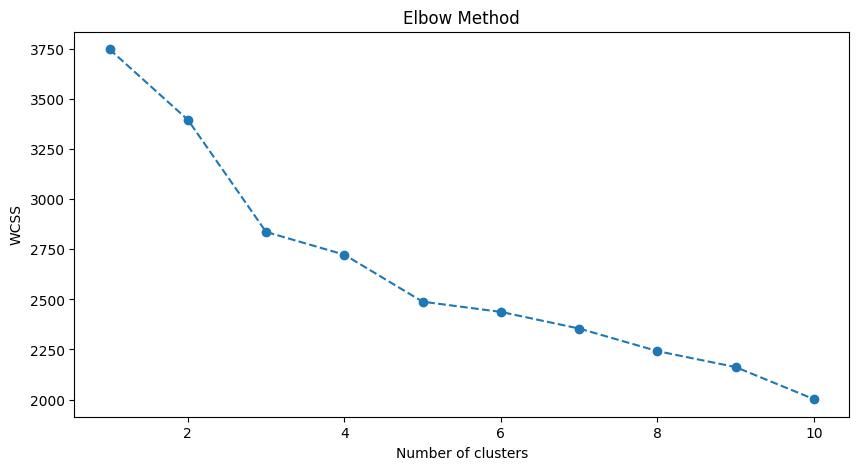

In [ ]:
from sklearn.cluster import KMeans


ss = []
max_clusters = 10

for k in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(scaled_imputed)
    ss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1, max_clusters+1), ss, marker="o", linestyle="--")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

- **PCA:** We used PCA with 3 components to project churned users into a lower-dimensional space. The first three PCs explain ~39% of the total variance, which suggests the churned-user behavior is high-dimensional. As a result, PCA is helpful for visual exploration, but it is not sufficient to fully represent the underlying structure of the data.

- **Elbow method** :When applying the Elbow method, the WCSS curve decreases smoothly without a clear “knee” point. This indicates that the cluster structure is not strongly separated in the current feature space (one-hot + scaled), so selecting an optimal K based solely on Elbow is inconclusive.

**Recommendations**

- Collect more useful churn behavior data (Ex: delivery delay/ETA, returns/refunds, customer support contacts, and recency/frequency of purchases). This will make the churn segments clearer and easier to explain.

- Run a small win-back test and save the results as new features. Try a few offers (free shipping / cashback / apology credit), then track who redeems and who buys again. Use these outcomes to improve the next round of clustering and targeting.
